In [1]:
import astropy
from astropy.io import fits
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from itables import show
import pprint

import itertools
from multiprocess import Pool
import multiprocess
from multiprocess import Manager
from threading import Thread

import os
import re
from tqdm import tqdm
from tqdm.contrib.concurrent import process_map  # or thread_map
import numpy as np
from scipy.interpolate import interp1d
# # from scipy.optimize import UnivariateSpline
from scipy.interpolate import interp1d, UnivariateSpline
import matplotlib.pyplot as plt
from astropy.io import fits
from FitsClass import FITSFile as myfits
from ObservationClass import ObservationManager as obsm
from SimulationClass import Simulations as sc
from bias_correction_sim import BinaryParams as BP

import specs as specs
from CCF import CCFclass

obs = obsm()

# Precalculations

## Calculating the mean errors of RV measurments of single stars

### Fitting it with a normal distribution

Finished with star Brey  70 and its RV erros are: [1.57715131 1.68871831 1.44300049 1.8942204  1.56907576 1.87980093] with mean 1.675 and std 0.166
Finished with star Brey  83 and its RV erros are: [3.05311338 2.42667083 1.78587887 1.92917381] with mean 2.299 and std 0.496
Finished with star H2013 LMCe  584 and its RV erros are: [1.65927489 1.51985208 2.11318301 1.81099012 1.45192833] with mean 1.711 and std 0.236
Finished with star HD  38030 and its RV erros are: [1.34290743 1.24454491 1.3462795  1.35483258 1.27089082 1.24514398] with mean 1.301 and std 0.048
Finished with star Brey  16a and its RV erros are: [3.06940535 3.256949   2.94432621 3.38060982 2.71623494 2.94850864] with mean 3.053 and std 0.218
Finished with star HD  32228 and its RV erros are: [2.55793003 2.21679429 3.00701774 2.42072796] with mean 2.551 and std 0.290
Finished with star HD  32402 and its RV erros are: [2.1223821  1.39244573 1.41420255 1.48235881 1.40065987 1.46400043] with mean 1.546 and std 0.260
Finished

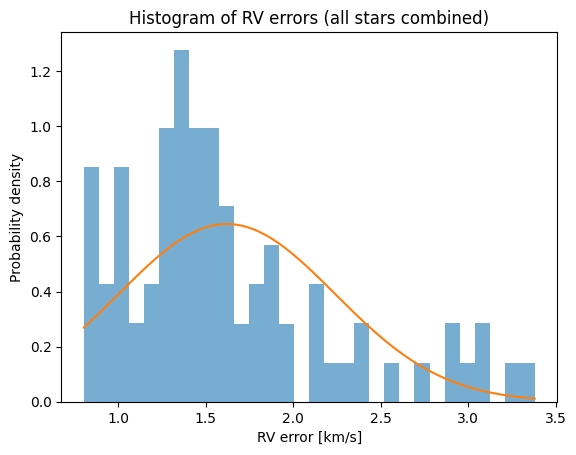

Mean RV error = 1.622 km/s
Std  RV error = 0.618 km/s


In [61]:
singles_list = ['Brey  70','Brey  83','H2013 LMCe  584','HD  38030','Brey  16a','HD  32228','HD  32402','HD  32257','HD 269818','HD  37680','HD  32125','HD  37026','Brey  93','HD 269888','Brey  90a']
RVs = {}
for single in singles_list:
    star = obs.load_star_instance(single)
    epochs = star.get_all_epoch_numbers()
    RV_list = np.zeros(len(epochs))
    for j in epochs:
        RV = star.load_property('RVs',j,'COMBINED')
        if RV:
            RV_list[j-1] = RV['C IV 5808-5812'].item()['full_RV_err']
    RVs[single] = RV_list[RV_list != 0]
    print(f'Finished with star {single} and its RV erros are: {RVs[single]} with mean {np.mean(RVs[single]):.3f} and std {np.std(RVs[single]):.3f}')

all_errs = np.concatenate([RVs[s] for s in singles_list if len(RVs[s]) > 0])

# mean + std (sample std)
mu_err = np.mean(all_errs)
sig_err = np.std(all_errs, ddof=1)

# histogram
import matplotlib.pyplot as plt

plt.figure()
counts, bins, _ = plt.hist(all_errs, bins=30, density=True, alpha=0.6)

# gaussian overlay
x = np.linspace(bins[0], bins[-1], 500)
gauss = (1.0/(sig_err*np.sqrt(2*np.pi))) * np.exp(-0.5*((x - mu_err)/sig_err)**2)
plt.plot(x, gauss)

plt.xlabel('RV error [km/s]')
plt.ylabel('Probability density')
plt.title('Histogram of RV errors (all stars combined)')

plt.show()

print(f"Mean RV error = {mu_err:.3f} km/s")
print(f"Std  RV error = {sig_err:.3f} km/s")

### Plotting the means of the stars

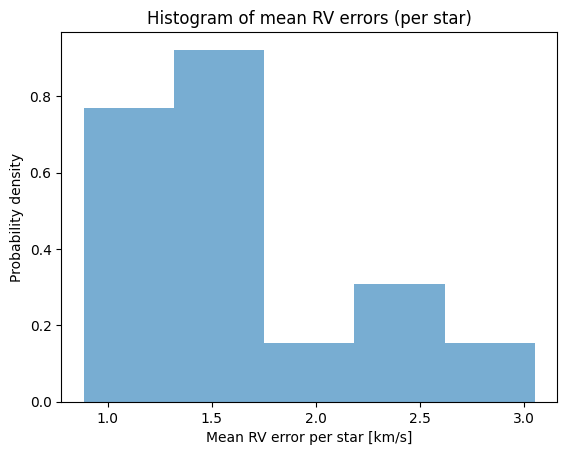


Per-star mean RV errors:
Brey  70         mean_err = 1.675 km/s
Brey  83         mean_err = 2.299 km/s
H2013 LMCe  584  mean_err = 1.711 km/s
HD  38030        mean_err = 1.301 km/s
Brey  16a        mean_err = 3.053 km/s
HD  32228        mean_err = 2.551 km/s
HD  32402        mean_err = 1.546 km/s
HD  32257        mean_err = 0.911 km/s
HD 269818        mean_err = 1.654 km/s
HD  37680        mean_err = 1.339 km/s
HD  32125        mean_err = 0.884 km/s
HD  37026        mean_err = 1.302 km/s
Brey  93         mean_err = 2.032 km/s
HD 269888        mean_err = 1.056 km/s
Brey  90a        mean_err = 1.539 km/s

Overall: mean of per-star means = 1.657 km/s
Overall: std  of per-star means = 0.609 km/s


In [64]:
# --- continue from your current code (don’t change anything above) ---

# 1) compute each star's mean RV error (over its non-zero epochs)
star_mean_err = {s: np.mean(RVs[s]) for s in singles_list if len(RVs[s]) > 0}
means = np.array(list(star_mean_err.values()))

# 2) histogram of per-star means
plt.figure()
plt.hist(means, bins='auto', density=True, alpha=0.6)

plt.xlabel('Mean RV error per star [km/s]')
plt.ylabel('Probability density')
plt.title('Histogram of mean RV errors (per star)')
plt.show()

# (optional) print them nicely
print("\nPer-star mean RV errors:")
for s in singles_list:
    if s in star_mean_err:
        print(f"{s:15s}  mean_err = {star_mean_err[s]:.3f} km/s")

print(f"\nOverall: mean of per-star means = {np.mean(means):.3f} km/s")
print(f"Overall: std  of per-star means = {np.std(means, ddof=1):.3f} km/s")


### Fitting Log-normal

Fitted log-normal parameters (ln-space):
mu_ln    = 0.4190
sigma_ln = 0.3535


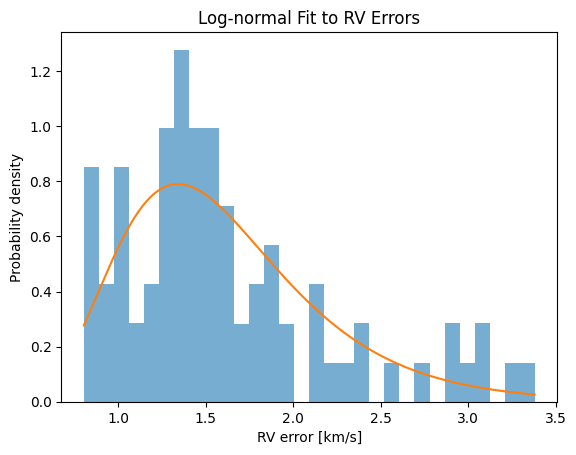

Implied mean (linear) = 1.6184 km/s
Implied std  (linear) = 0.5904 km/s


In [48]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import lognorm

# --- FIT LOGNORMAL ---
# scipy's lognorm: shape = s (sigma of ln), scale = exp(mu_ln)
shape, loc, scale = lognorm.fit(all_errs, floc=0)  # force loc=0 (standard lognormal)

mu_ln = np.log(scale)
sigma_ln = shape

print("Fitted log-normal parameters (ln-space):")
print(f"mu_ln    = {mu_ln:.4f}")
print(f"sigma_ln = {sigma_ln:.4f}")

# --- PLOT HISTOGRAM ---
plt.figure()
plt.hist(all_errs, bins=30, density=True, alpha=0.6)

# --- PLOT FITTED PDF ---
x = np.linspace(all_errs.min(), all_errs.max(), 500)
pdf = lognorm.pdf(x, s=shape, loc=loc, scale=scale)
plt.plot(x, pdf)

plt.xlabel("RV error [km/s]")
plt.ylabel("Probability density")
plt.title("Log-normal Fit to RV Errors")
plt.show()

# (optional) mean/std in linear space implied by the fitted lognormal
mean_lin = lognorm.mean(s=shape, loc=loc, scale=scale)
std_lin  = lognorm.std(s=shape, loc=loc, scale=scale)
print(f"Implied mean (linear) = {mean_lin:.4f} km/s")
print(f"Implied std  (linear) = {std_lin:.4f} km/s")


## Getting all RVs and assigning the $\Delta RV$ of each star for the K-S test later

In [2]:
import numpy as np

# free parameter you can tune (km/s)
threshold_dRV = 45.5

RVs      = {}
RV_errs  = {}
dRV_dict = {}
dRV_err  = {}

for star_name in specs.star_names:
    star   = obs.load_star_instance(star_name)
    epochs = star.get_all_epoch_numbers()

    RV_list     = np.zeros(len(epochs))
    RV_err_list = np.zeros(len(epochs))

    # pull RVs and errors
    for j in epochs:
        RV = star.load_property('RVs', j, 'COMBINED')
        if RV:
            line_dict = RV['C IV 5808-5812'].item()
            RV_list[j-1]     = line_dict['full_RV']       # RV value
            RV_err_list[j-1] = line_dict['full_RV_err']   # RV error

    # keep only non-zero entries (in case some epochs are missing)
    rv     = RV_list[RV_list != 0]
    rv_err = RV_err_list[RV_list != 0]

    RVs[star_name]     = rv
    RV_errs[star_name] = rv_err

    if len(rv) < 2:
        dRV_dict[star_name] = 0.0
        dRV_err[star_name]  = np.nan
        print(f'star {star_name}: fewer than 2 RV points, setting dRV=0')
        continue

    # -----------------------------
    # 1) Start with min–max pair
    # -----------------------------
    idx_min = np.argmin(rv)
    idx_max = np.argmax(rv)

    rv_min = rv[idx_min]
    rv_max = rv[idx_max]

    base_dRV   = rv_max - rv_min
    abs_base   = abs(base_dRV)
    sigma_base = np.sqrt(rv_err[idx_min]**2 + rv_err[idx_max]**2)

    # initial "best" choice is the full min–max baseline
    best_dRV   = abs_base
    best_sigma = sigma_base

    # test significance for min–max
    found_significant = (abs_base > threshold_dRV) and ((abs_base - 4.0 * sigma_base) > 0.0)

    # ------------------------------------------
    # 2) If min–max fails, scan all other pairs
    # ------------------------------------------
    if not found_significant:
        for i in range(len(rv)):
            for k in range(i+1, len(rv)):
                # optionally skip the already-tested min–max pair
                if (i == idx_min and k == idx_max) or (i == idx_max and k == idx_min):
                    continue

                dRV_ik   = rv[k] - rv[i]
                abs_dRV  = abs(dRV_ik)
                sigma_ik = np.sqrt(rv_err[i]**2 + rv_err[k]**2)

                if abs_dRV > threshold_dRV and (abs_dRV - 4.0 * sigma_ik) > 0.0:
                    # keep the largest |dRV| that satisfies the condition
                    if abs_dRV > best_dRV:
                        best_dRV   = abs_dRV
                        best_sigma = sigma_ik
                        found_significant = True

    # -----------------------------
    # 3) Store the result
    # -----------------------------
    dRV_dict[star_name] = best_dRV
    dRV_err[star_name]  = best_sigma

    if found_significant:
        print(
            f'Finished star {star_name}: used SIGNIFICANT pair, '
            f'dRV={best_dRV:.3f} km/s, sigma_pair={best_sigma:.3f} km/s'
        )
    else:
        print(
            f'Finished star {star_name}: NO significant pair, '
            f'falling back to min–max, dRV={best_dRV:.3f} km/s, '
            f'sigma_pair={best_sigma:.3f} km/s'
        )

# print(dRV_dict)

Finished star Brey  70: NO significant pair, falling back to min–max, dRV=27.600 km/s, sigma_pair=2.538 km/s
Finished star Brey  83: NO significant pair, falling back to min–max, dRV=27.523 km/s, sigma_pair=3.900 km/s
Spectral type not found in the SIMBAD response.
Finished star HD  38029: used SIGNIFICANT pair, dRV=77.866 km/s, sigma_pair=5.986 km/s
Finished star HD  37248: used SIGNIFICANT pair, dRV=148.928 km/s, sigma_pair=2.091 km/s
Finished star Brey  95a: used SIGNIFICANT pair, dRV=149.775 km/s, sigma_pair=5.454 km/s
BAT99 identifier not found. The indexes were: -1 and 39. It found sion="1.0" encoding="UTF-8" ?>
Finished star MNM2014 LMC195-1: used SIGNIFICANT pair, dRV=59.897 km/s, sigma_pair=6.852 km/s
Finished star HD  32125: NO significant pair, falling back to min–max, dRV=11.038 km/s, sigma_pair=1.213 km/s
Finished star HD  37026: NO significant pair, falling back to min–max, dRV=8.400 km/s, sigma_pair=1.661 km/s
Finished star HD 269818: NO significant pair, falling back to

In [2]:
import numpy as np
from concurrent.futures import ThreadPoolExecutor, as_completed

# free parameter you can tune (km/s)
threshold_dRV = 45.5

def process_star(star_name):
    star   = obs.load_star_instance(star_name)
    epochs = star.get_all_epoch_numbers()

    RV_list     = np.zeros(len(epochs))
    RV_err_list = np.zeros(len(epochs))

    # pull RVs and errors — all epochs in one go per star
    for j in epochs:
        RV = star.load_property('RVs', j, 'COMBINED')
        if RV:
            line_dict    = RV['C IV 5808-5812'].item()
            RV_list[j-1]     = line_dict['full_RV']
            RV_err_list[j-1] = line_dict['full_RV_err']

    # keep only non-zero entries
    rv     = RV_list[RV_list != 0]
    rv_err = RV_err_list[RV_list != 0]

    if len(rv) < 2:
        return star_name, rv, rv_err, 0.0, np.nan, False

    # 1) min-max pair
    idx_min, idx_max = np.argmin(rv), np.argmax(rv)
    abs_base   = abs(rv[idx_max] - rv[idx_min])
    sigma_base = np.sqrt(rv_err[idx_min]**2 + rv_err[idx_max]**2)
    best_dRV, best_sigma = abs_base, sigma_base
    found_significant = (abs_base > threshold_dRV) and ((abs_base - 4.0 * sigma_base) > 0.0)

    # 2) scan all other pairs if needed
    if not found_significant:
        for i in range(len(rv)):
            for k in range(i+1, len(rv)):
                if (i == idx_min and k == idx_max) or (i == idx_max and k == idx_min):
                    continue
                abs_dRV  = abs(rv[k] - rv[i])
                sigma_ik = np.sqrt(rv_err[i]**2 + rv_err[k]**2)
                if abs_dRV > threshold_dRV and (abs_dRV - 4.0 * sigma_ik) > 0.0:
                    if abs_dRV > best_dRV:
                        best_dRV, best_sigma = abs_dRV, sigma_ik
                        found_significant = True

    return star_name, rv, rv_err, best_dRV, best_sigma, found_significant

# --- run all stars in parallel (IO-bound → threads) ---
RVs      = {}
RV_errs  = {}
dRV_dict = {}
dRV_err  = {}
obs_single_rv = []
obs_binary_rv = []
obs_is_binary = {}

with ThreadPoolExecutor() as executor:
    futures = {executor.submit(process_star, name): name for name in specs.star_names}
    for future in as_completed(futures):
        star_name, rv, rv_err, best_dRV, best_sigma, found_significant = future.result()

        RVs[star_name]     = rv
        RV_errs[star_name] = rv_err
        dRV_dict[star_name] = best_dRV
        dRV_err[star_name]  = best_sigma

        is_binary = found_significant
        obs_is_binary[star_name] = is_binary

        if len(rv) < 2:
            print(f'star {star_name}: fewer than 2 RV points, setting dRV=0')
        elif is_binary:
            obs_binary_rv.append(rv)
            print(f'Finished star {star_name}: SIGNIFICANT pair, dRV={best_dRV:.3f} km/s, sigma={best_sigma:.3f} km/s')
        else:
            obs_single_rv.append(rv)
            print(f'Finished star {star_name}: NO significant pair, falling back to min-max, dRV={best_dRV:.3f} km/s, sigma={best_sigma:.3f} km/s')

# flatten to 1D
obs_single_rv = np.concatenate(obs_single_rv) if obs_single_rv else np.empty(0)
obs_binary_rv = np.concatenate(obs_binary_rv) if obs_binary_rv else np.empty(0)

print(f'\nObserved RV points: singles={obs_single_rv.size}, binaries={obs_binary_rv.size}')

BAT99 identifier not found. The indexes were: -1 and 39. It found sion="1.0" encoding="UTF-8" ?>
Finished star HD  32125: NO significant pair, falling back to min-max, dRV=11.038 km/s, sigma=1.213 km/s
Finished star Brey  83: NO significant pair, falling back to min-max, dRV=27.523 km/s, sigma=3.900 km/s
Finished star HD  37248: SIGNIFICANT pair, dRV=148.928 km/s, sigma=2.091 km/s
Finished star HD 269818: NO significant pair, falling back to min-max, dRV=12.102 km/s, sigma=2.280 km/s
BAT99 identifier not found. The indexes were: -1 and 39. It found sion="1.0" encoding="UTF-8" ?>
Finished star Brey  70: NO significant pair, falling back to min-max, dRV=27.600 km/s, sigma=2.538 km/s
Finished star HD  32228: NO significant pair, falling back to min-max, dRV=12.584 km/s, sigma=3.385 km/s
Finished star Brey  95a: SIGNIFICANT pair, dRV=149.775 km/s, sigma=5.454 km/s
Finished star HD  32257: NO significant pair, falling back to min-max, dRV=12.254 km/s, sigma=1.294 km/s
Spectral type not foun

## Pulling MJDs of all stars

In [3]:
MJDs = {}
for star_name in specs.star_names:
    star = obs.load_star_instance(star_name,to_print=False)
    epochs = star.get_all_epoch_numbers()
    MJD_list = []
    for j in epochs:
        fit = star.load_observation(j,band = 'NIR')
        # fit.print_file_info()
        MJD_list.append(fit.header['MJD-OBS'])
    MJDs[star_name] = MJD_list
    print(f'Finished for star {star_name}')

# Absolute MJDs

# flatten all MJDs and get global minimum
all_mjds = np.concatenate([np.asarray(mjds, dtype=float) for mjds in MJDs.values()])
global_min_mjd = all_mjds.min()
mjd_rel_dict = {
    name: np.asarray(mjds, dtype=float) - global_min_mjd
    for name, mjds in MJDs.items()
}
# print(mjd_rel_dict)


Finished for star Brey  70
Finished for star Brey  83
Finished for star HD  38029
Finished for star HD  37248
Finished for star Brey  95a
Finished for star MNM2014 LMC195-1
Finished for star HD  32125
Finished for star HD  37026
Finished for star HD 269818
Finished for star HD  38448
Finished for star HD  38030
Finished for star HD  37680
Finished for star Brey  58a
Finished for star HD  32228
Finished for star HD  32257
Finished for star HD 269888
Finished for star HD  36156
Finished for star H2013 LMCe  584
Finished for star RMC 140
Finished for star HD  32402
Finished for star Brey  70a
Finished for star Brey  16a
Finished for star Brey  93
Finished for star Brey  90a
Finished for star HD 269891


# Bias correction runs

## Basic Dsilva‑style grid (power‑law log P)

In [25]:
import numpy as np
from wr_bias_simulation import (
    SimulationConfig, BinaryParameterConfig,
    run_bias_grid, plot_ks_heatmap,
    plot_best_cdf,
    plot_best_detection_fraction_vs_threshold,
    plot_best_rv_distributions,
    plot_3d_ks,
    plot_ks_movie,
)

# 0) Build cadence_library from your mjd_rel_dict (times already MJD - global_min)
# mjd_rel_dict: { star_name: array_of_times_in_days_since_global_min, ... }
cadence_library = [
    np.asarray(t, dtype=float)
    for t in mjd_rel_dict.values()
]

# 1) Your observed ΔRV values (km/s) as a 1D array
obs_delta_rv = np.array(list(dRV_dict.values()))  # fill with your data

# 2) Set up configs
sim_cfg = SimulationConfig(
    n_stars=3000,
    # n_epochs and time_span are ignored when cadence_library is given
    n_epochs=6,
    time_span=2000.0,
    # sigma_single=np.sqrt(10**2+1.622**2),        # std of single-star Gaussian (km/s)
    sigma_single = 5.5,
    sigma_measure=1.622,      # per-epoch measurement error (km/s)
    v_sys=0.0,
    cadence_library=cadence_library
    # cadence_weights=...     # optional, if you ever want to weight some stars more
)

bin_cfg = BinaryParameterConfig(
    logP_min=0.15,        # ~= 1 day
    logP_max=5.0,         # 10^5 days
    period_model="powerlaw",
    e_model="flat",       # e ~ U[0, 0.9]
    e_max=0.9,
    mass_primary_model="fixed",
    mass_primary_fixed=10.0,
    q_model="flat",
    q_range=(0.1, 2.0)    # Dsilva-like q range
)

# 3) Define your (f_bin, π) grid
fbin_grid = np.linspace(0.01, 0.99, 17*8+1)       # 0.1..0.9
pi_grid   = np.linspace(-3.0, 3.0, 31*8+1)      # Dsilva-like π range

# 4) Run the full grid in parallel
# result_powerlaw = run_bias_grid(
#     fbin_values=fbin_grid,
#     pi_values=pi_grid,
#     obs_delta_rv=obs_delta_rv,
#     sim_cfg=sim_cfg,
#     bin_cfg=bin_cfg,
#     period_model="powerlaw",   # use π
#     n_processes=11,            # or e.g. 8
#     seed_base=42,
#     use_multiprocessing=True
# )
# result_powerlaw["ks_D"] = result_powerlaw["ks_D"][0]
# result_powerlaw["ks_p"] = result_powerlaw["ks_p"][0]

# Run the 3D grid
result_3d = run_bias_grid(
    fbin_values=fbin_grid,
    pi_values=pi_grid,
    obs_delta_rv=obs_delta_rv,
    sim_cfg=sim_cfg,
    bin_cfg=bin_cfg,
    period_model="powerlaw",   # use π
    n_processes=12,            # or e.g. 8
    seed_base=42,
    use_multiprocessing=True,
    sigma_values=np.linspace(4, 7, 70),  # e.g. 5 to 15 km/s in steps of 1
)

Bias grid (powerlaw, 70 σ slice(s)):   0%|          | 0/2387910 [00:00<?, ?it/s]

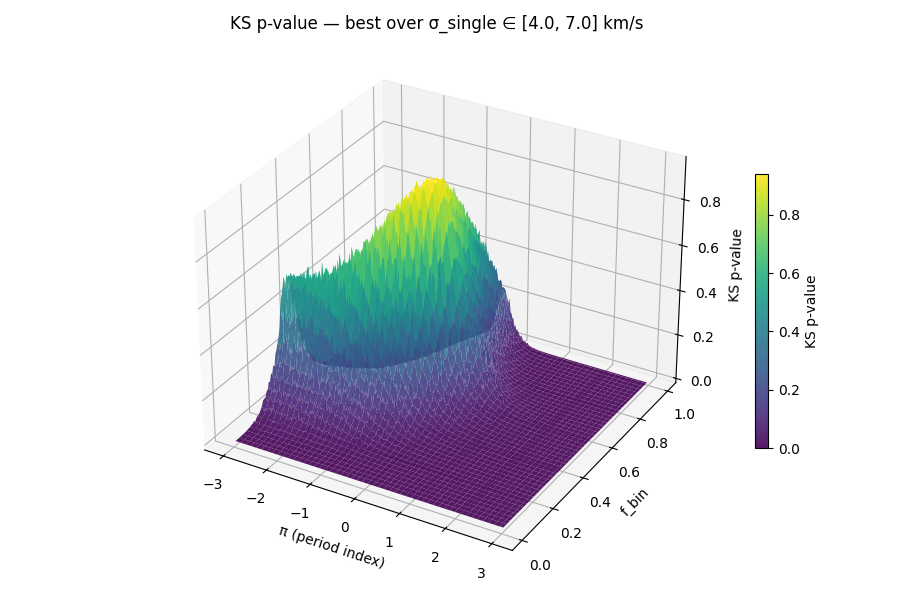

In [26]:
# 3D surface (best over sigma)
%matplotlib widget
fig3d, ax3d = plot_3d_ks(result_3d, use_pvalue=True)

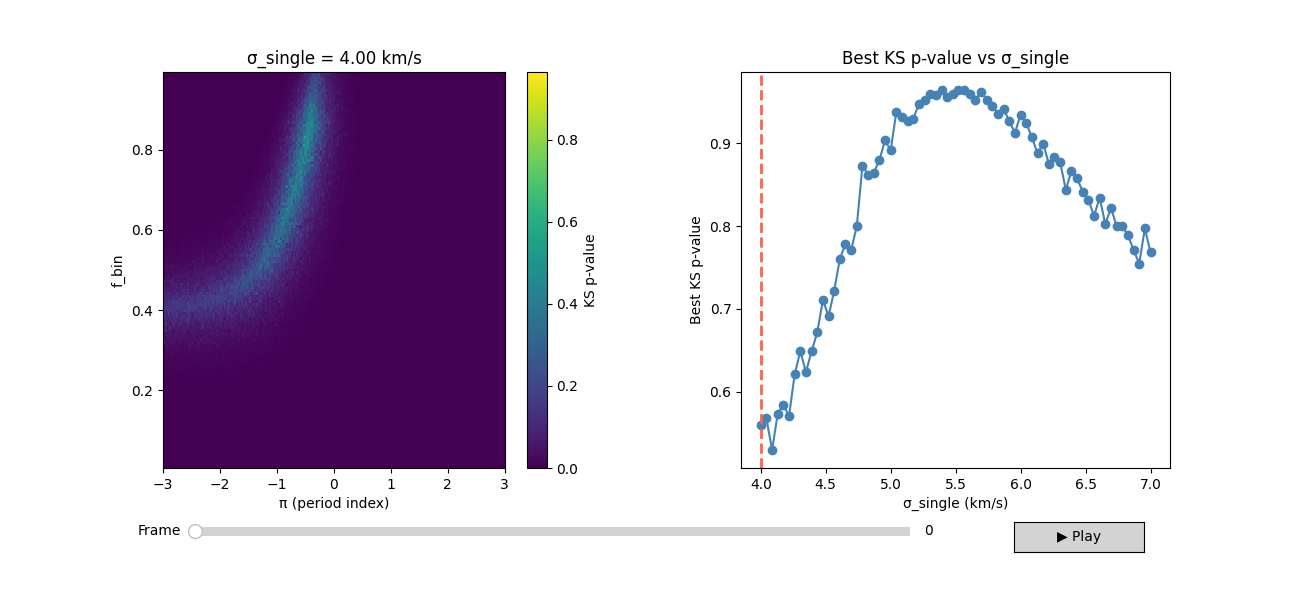

In [27]:
# Animated movie
%matplotlib widget
fig_mov, anim = plot_ks_movie(result_3d, use_pvalue=True)

Best f_bin  = 0.543
Best π      = -0.605
Best p-value = 0.9577


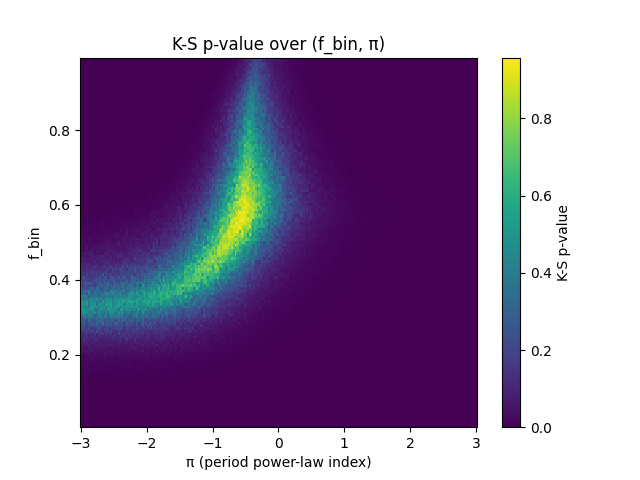

In [24]:
%matplotlib widget
ax = plot_ks_heatmap(result_powerlaw, use_pvalue=True)

best_idx = np.unravel_index(np.argmax(result_powerlaw["ks_p"]), result_powerlaw["ks_p"].shape)
best_fbin = result_powerlaw["fbin_grid"][best_idx[0]]
best_pi   = result_powerlaw["pi_grid"][best_idx[1]]
best_p    = result_powerlaw["ks_p"][best_idx]

print(f"Best f_bin  = {best_fbin:.3f}")
print(f"Best π      = {best_pi:.3f}")
print(f"Best p-value = {best_p:.4f}")

Best (f_bin, pi) = 0.6152941176470589 -0.048387096774193505


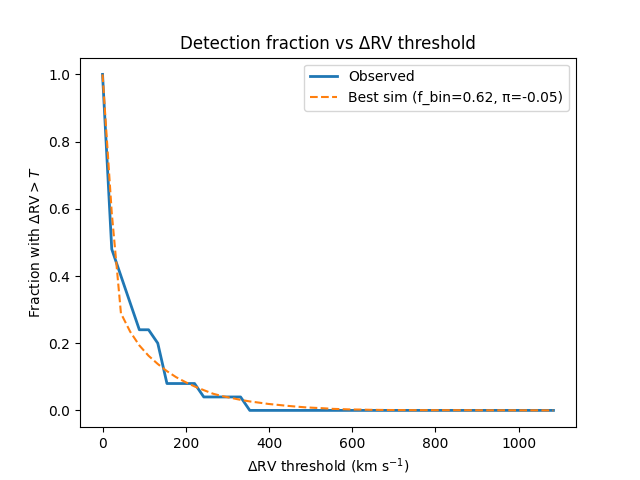

In [9]:
# CDF comparison
ax_cdf, best_fbin, best_pi = plot_best_cdf(
    grid_result=result_powerlaw,
    obs_delta_rv=obs_delta_rv,
    sim_cfg=sim_cfg,
    bin_cfg=bin_cfg,          # the BinaryParameterConfig you used for the grid
    period_model="powerlaw",
    by="p",                   # maximise p-value
    seed=1234,
)

print("Best (f_bin, pi) =", best_fbin, best_pi)

ax_det, best_fbin2, best_pi2 = plot_best_detection_fraction_vs_threshold(
    grid_result=result_powerlaw,
    obs_delta_rv=obs_delta_rv,
    sim_cfg=sim_cfg,
    bin_cfg=bin_cfg,
    period_model="powerlaw",
    by="p",
    seed=5678,                # different seed if you want an independent sample
)


Best (f_bin, pi) for RV distributions: 0.6152941176470589 -0.048387096774193505


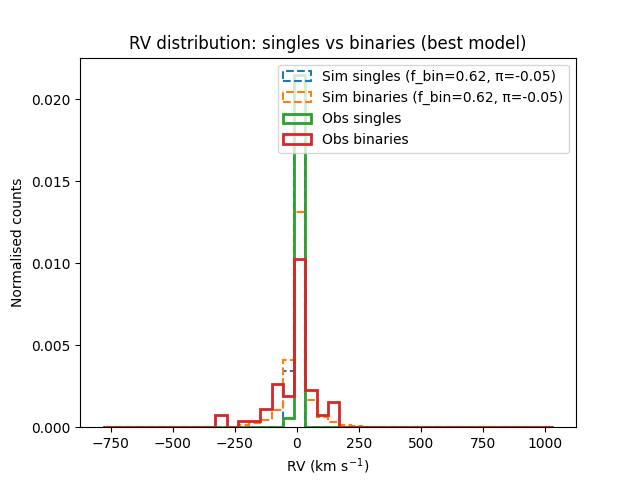

In [10]:
%matplotlib widget
ax_rv, best_fbin, best_pi = plot_best_rv_distributions(
    grid_result=result_powerlaw,
    sim_cfg=sim_cfg,
    bin_cfg=bin_cfg,
    obs_single_rv=obs_single_rv,
    obs_binary_rv=obs_binary_rv,
)

print("Best (f_bin, pi) for RV distributions:", best_fbin, best_pi)

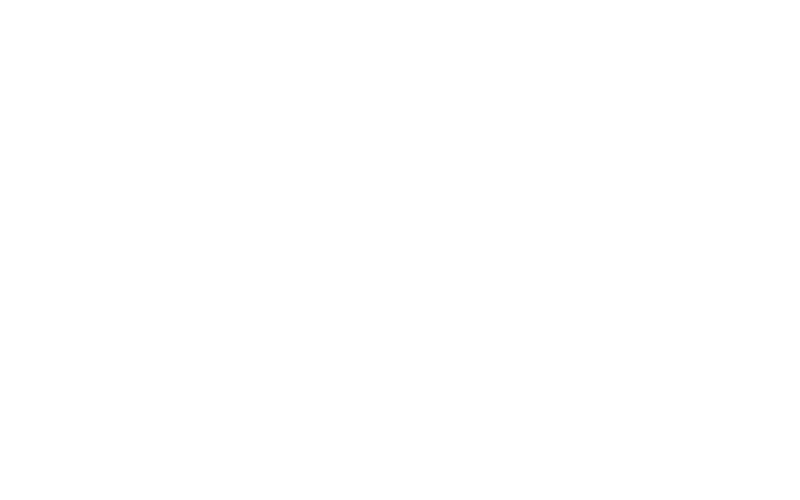

Fitted Gaussian:  μ = 4.84 km/s,  σ = 7.83 km/s
N measurements:   82
χ²/dof:           14.14 / 6  →  p = 0.028

Note: σ = 7.83 km/s is your empirical sigma_single for the simulation.


In [41]:
from scipy.stats import norm, chi2
import matplotlib.pyplot as plt
import numpy as np

# --- fit Gaussian to observed single-star RVs ---
mu_fit, sigma_fit = norm.fit(obs_single_rv)

# goodness of fit: chi-squared on histogram bins
counts, bin_edges = np.histogram(obs_single_rv, bins='auto', density=False)
bin_centres = 0.5 * (bin_edges[:-1] + bin_edges[1:])
bin_width   = np.diff(bin_edges)

# expected counts under fitted Gaussian
expected = norm.pdf(bin_centres, mu_fit, sigma_fit) * bin_width * len(obs_single_rv)

# only use bins with enough expected counts for chi2 to be valid
mask     = expected > 3
chi2_stat = np.sum((counts[mask] - expected[mask])**2 / expected[mask])
dof       = mask.sum() - 2  # 2 fitted parameters (mu, sigma)
p_chi2    = 1.0 - chi2.cdf(chi2_stat, dof)

# --- plot ---
fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(
    obs_single_rv,
    bins='auto',
    # bins = 25,
    density=True,
    alpha=0.55,
    color='steelblue',
    label='Observed singles',
)

x = np.linspace(obs_single_rv.min() - 20, obs_single_rv.max() + 20, 500)
ax.plot(
    x, norm.pdf(x, mu_fit, sigma_fit),
    color='tomato', lw=2,
    label=(
        f'Gaussian fit\n'
        f'μ = {mu_fit:.1f} km/s\n'
        f'σ = {sigma_fit:.1f} km/s\n'
        f'N = {len(obs_single_rv)}\n'
        f'χ²/dof = {chi2_stat:.1f}/{dof}\n'
        f'p(χ²) = {p_chi2:.3f}'
    )
)

# mark mu and ±1σ, ±2σ
for k, ls in zip([1, 2], ['--', ':']):
    ax.axvline(mu_fit + k * sigma_fit, color='tomato', lw=1, ls=ls, alpha=0.6)
    ax.axvline(mu_fit - k * sigma_fit, color='tomato', lw=1, ls=ls, alpha=0.6)
ax.axvline(mu_fit, color='tomato', lw=1.5, ls='-', alpha=0.8)

ax.set_xlabel(r'RV (km s^{-1})')
ax.set_ylabel('Probability density')
ax.set_title('RV distribution of observed single stars — Gaussian fit')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print(f"Fitted Gaussian:  μ = {mu_fit:.2f} km/s,  σ = {sigma_fit:.2f} km/s")
print(f"N measurements:   {len(obs_single_rv)}")
print(f"χ²/dof:           {chi2_stat:.2f} / {dof}  →  p = {p_chi2:.3f}")
print(f"\nNote: σ = {sigma_fit:.2f} km/s is your empirical sigma_single for the simulation.")

## Langer+2020‑style period distribution

In [7]:
# 0) Choose how many cores to use
n_cores = 11
n_proc  = min(11, n_cores)   # or just set n_proc = 11 explicitly

# 1) Langer+2020 period model config
bin_cfg_langer = BinaryParameterConfig(
    logP_min=0.5,          # roughly 3 days
    logP_max=3.5,          # ~3000 days
    period_model="langer2020",
    langer_period_params=dict(
        mu_A=1.1, sigma_A=0.15,   # tweak these to match Langer+2020
        mu_B=2.2, sigma_B=0.35,
        weight_A=0.3
    ),
    e_model="zero",        # e = 0 as in Langer
    mass_primary_model="fixed",
    mass_primary_fixed=15.0,  # or a range if you want
    q_model="langer"          # crude Langer-like q distribution
)

# 2) Grid: mostly over f_bin, π is just a dummy (ignored by langer2020)
fbin_grid = np.linspace(0.1, 0.9, 17)
pi_grid   = [0.0]  # dummy column

# 3) Run grid with Langer periods, using SAME sim_cfg (with cadence_library)
result_langer = run_bias_grid(
    fbin_values=fbin_grid,
    pi_values=pi_grid,
    obs_delta_rv=obs_delta_rv,   # your per-star ΔRV from data
    sim_cfg=sim_cfg,             # already has cadence_library, sigma_single, etc.
    bin_cfg=bin_cfg_langer,
    period_model="langer2020",
    n_processes=n_proc,
    seed_base=42,
    use_multiprocessing=True
)




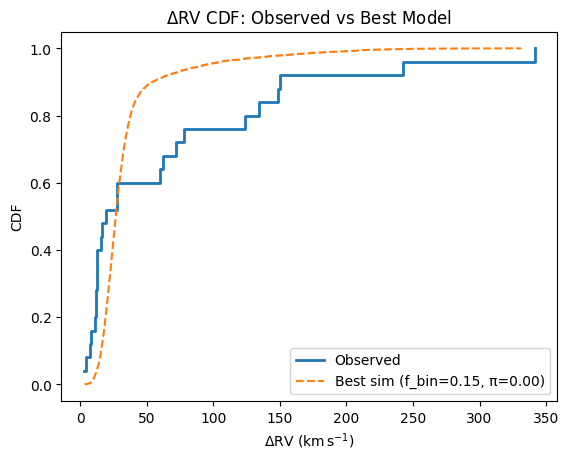

In [8]:
ax_cdf_L, best_f_L, best_pi_L = plot_best_cdf(
    grid_result=result_langer,
    obs_delta_rv=obs_delta_rv,
    sim_cfg=sim_cfg,
    bin_cfg=bin_cfg_langer,
    period_model="langer2020",
    by="p",
)


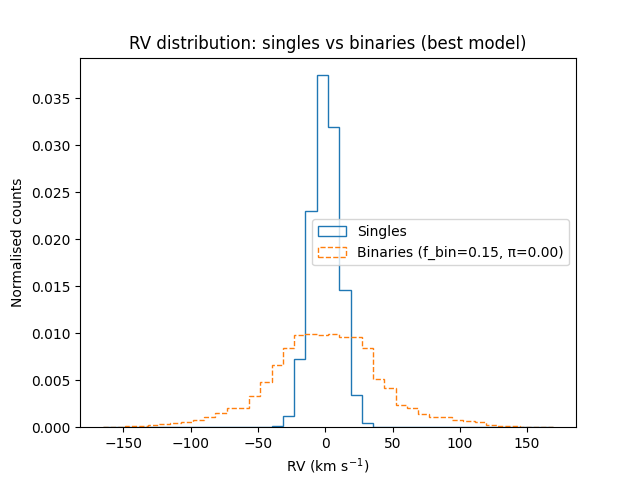

In [11]:
%matplotlib widget
ax_rv_L, best_f_L, best_pi_L = plot_best_rv_distributions(
    grid_result=result_langer,
    sim_cfg=sim_cfg,
    bin_cfg=bin_cfg_langer,
    period_model="langer2020",
    by="p",
    seed=1234,
    bins=40,
)
